In [8]:
import pandas as pd
from pandas.tseries.offsets import BDay
import yfinance as yf
import requests
import matplotlib.pyplot as plt

In [9]:
wiki = 'https://en.wikipedia.org/wiki/'
url_dow = wiki + 'AEX_index'

# Use requests to get the HTML content
html_dow = requests.get(url_dow).content

# Use pandas to read the HTML tables
df_list = pd.read_html(html_dow, flavor='bs4')

total = pd.DataFrame()
# Find the correct table and column name for the ticker symbols
for df in df_list:
    if 'Ticker symbol' in df.columns:
        tickers = df['Ticker symbol'].tolist()
        break
#tickers = pd.Series(['VLK'])
for ticker in tickers:
    ticker = ticker + '.AS'
    t_hist = yf.Ticker(ticker).history(period="10y",auto_adjust=False)
 #   t_hist = yf.Ticker(ticker).history(start='2021-01-01',end='2021-12-31',auto_adjust=False)
    t_hist['Ticker'] = ticker
    total = pd.concat([total, t_hist])
    #print(t_hist)
    

URW.AS: No data found, symbol may be delisted
/var/folders/k3/7tqt3gf901qcwch_7zht4th00000gn/T/ipykernel_64969/2670147368.py:22: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  total = pd.concat([total, t_hist])


In [10]:
def dividend_analysis_oud(df, x=10):
    frames = []
    grouped = df.groupby('Ticker')
    
    for ticker, data in grouped:
        # Ensure 'Date' is the index if not already set - Important for loc to work correctly
        if data.index.name != 'Date':
            data = data.set_index('Date')
        
        for date, row in data[data['Dividends'] > 0].iterrows():
            start = date - pd.DateOffset(days=x)
            end = date + pd.DateOffset(days=x)
            
            # Using loc to define a window around each dividend date and making a copy to avoid SettingWithCopyWarning
            window = data.loc[start:end].copy()  
            
            window.loc[:, 'Day Index'] = (window.index - date).days
            dividend_adj_close = row['Adj Close']
            window.loc[:, 'Percent Difference'] = ((window['Adj Close'] - dividend_adj_close) / dividend_adj_close) * 100
            
            frames.append(window)
    
    result = pd.concat(frames)
    result = result.reset_index().set_index(['Ticker', 'Day Index'])
    return result

In [11]:
def dividend_analysis(df, x=20, use_business_days=True):
    frames = []
    grouped = df.groupby('Ticker')
    
    for ticker, data in grouped:
        # Ensure 'Date' is the index if not already set - Important for loc to work correctly
        if data.index.name != 'Date':
            data = data.set_index('Date')
        
        for date, row in data[data['Dividends'] > 0].iterrows():
            if use_business_days:
                # Bepaal de range van werkdagen voor en na de dividend datum
                pre_dividend_dates = pd.date_range(end=date-pd.DateOffset(days=1), periods=x, freq=BDay())
                post_dividend_dates = pd.date_range(start=date+BDay(), periods=x, freq=BDay())
                date_range = pre_dividend_dates.union(post_dividend_dates)
            else:
                # Bepaal de range van kalenderdagen voor en na de dividend datum
                date_range = pd.date_range(start=date-pd.DateOffset(days=x), end=date+pd.DateOffset(days=x), freq='D')

            # Reindexeer de DataFrame om alleen de geselecteerde dagen te bevatten
            window = data.reindex(date_range).copy()
            
            # Bepaal de 'Day Index' voor de geselecteerde dagen
            window['Day Index'] = (window.index - date).days
            dividend_adj_close = row['Adj Close']
#            dividend_adj_close = row['Close']
            
            # Bereken het percentage verschil ten opzichte van de aangepaste sluitprijs op de dividenddatum
#            window['Percent Difference'] = ((window['Close'] - dividend_adj_close) / dividend_adj_close) * 100
            window['Percent Difference'] = ((window['Adj Close'] - dividend_adj_close) / dividend_adj_close) * 100
            
            frames.append(window)
    
    result = pd.concat(frames)
    
    # Reset index om netjes te maken
    result.reset_index(inplace=True)
    result.set_index(['Ticker', 'Day Index'], inplace=True)
    return result

In [12]:
def plot_dividend_periods(df):
    plt.figure(figsize=(14, 7))
    plt.title('Stock Performance Around Dividend Dates')
    
    # Bereken het gemiddelde van Percent Difference voor elke 'Day Index'
    mean_performance = df.groupby('Day Index')['Percent Difference'].mean()

    # Haal unieke tickers op
    unique_tickers = df.index.get_level_values('Ticker').unique()
    
    # Plot elke ticker's performance als een licht transparante lijn
    for ticker in unique_tickers:
        ticker_data = df.xs(ticker, level='Ticker')
        plt.plot(ticker_data.index, ticker_data['Percent Difference'], alpha=0.1)  # Meer transparantie toegevoegd

    # Teken de gemiddelde lijn, duidelijker en dikker
    plt.plot(mean_performance.index, mean_performance, color='black', linewidth=2.5, label='Average Performance')

    # Teken een verticale lijn op dag 0 om de dividend datum te markeren
    plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Dividend Date')

    # Configureer de legenda (verwijder commentaar indien de legenda gewenst is)
    # plt.legend(title='Legend', loc='upper left')

    # Labels en grid voor leesbaarheid
    plt.ylabel('Percent Difference (%)')
    plt.xlabel('Days Relative to Dividend Date')
    plt.grid(True)
    
    # Toon de grafiek
    plt.show()

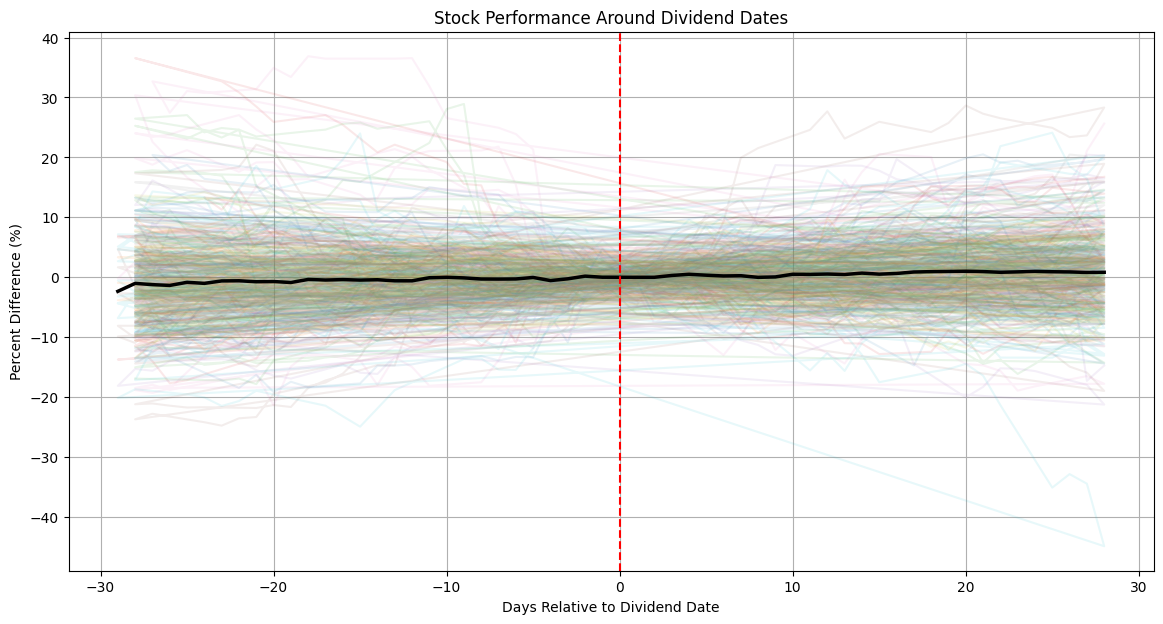

In [13]:
# Gebruik de functies
result_df = dividend_analysis(total)  # replace 'your_dataframe' with the actual DataFrame name
plot_dividend_periods(result_df)  # Zorg dat result_df de dataframe is die van dividend_analysis komt
